In [1]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
from scipy import integrate
sys.path.append('../')
from Scattering_Simulator import pairwise_method
from Scattering_Simulator import Read_PDB

This notebook was used to simulate the small angle scattering curve of the ferritin protein cage and compare it with the experimental data. 

In [2]:
def extract_data(file_path):
    """
    Extract numeric data from a .dat file.
    Skips comment lines starting with # or non-numeric rows.
    Returns numpy array and pandas DataFrame.
    """

    data = []

    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()

            # Skip empty lines and comments
            if not line or line.startswith("#"):
                continue

            try:
                # Split by whitespace and convert to float
                row = [float(value) for value in line.split()]
                data.append(row)
            except ValueError:
                # Skip lines that can't be converted to float
                continue

    if not data:
        raise ValueError("No numeric data found in file.")

    data_array = np.array(data)

    # Create DataFrame with generic column names
    columns = [f"col_{i+1}" for i in range(data_array.shape[1])]
    df = pd.DataFrame(data_array, columns=columns)

    return data_array, df

## Load the Coordinates of the Protein Crystal
The struture of the protein cage is visualized in a 2D plot.

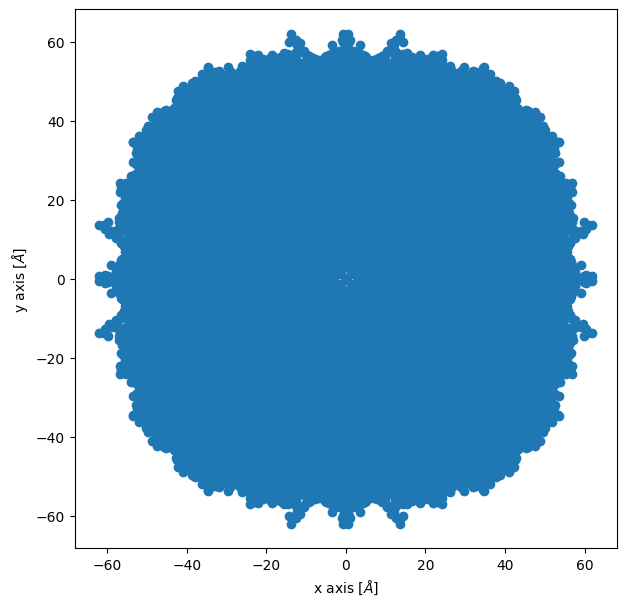

In [3]:
coords = Read_PDB.load_pdb_SANS('../Data/PDB/ferritin_pdb.pdb') 
fig, ax = plt.subplots(figsize=(7,7))
plt.scatter(coords[:,0], coords[:,2])
plt.xlabel('x axis [$\\AA$]')
plt.ylabel('y axis [$\\AA$]')
coordinates = coords

## Sample from the Building Block
This performs the simulation of the structure to the scattering curve using the MC-DFM.  

In [4]:
n_samples = 10000000 #number of pairwise distances to create the pairwise distribution
simulator = pairwise_method.scattering_simulator(n_samples)
simulator.sample_building_block(coordinates) 
simulator.use_building_block_as_structure()

In [5]:
histogram_bins = 10000 #number of points in the pairwise distribution
#q = np.geomspace(0.005, 0.2, 3000) #The q-range of the simulated scattering curve 
q = np.geomspace(0.005, 0.6, 3000)
I_q = simulator.simulate_scattering_curve_fast(coordinates, histogram_bins, q, save=True)

## Plot the Results
The results of the simulation is compared to experimental data.

In [6]:
exp_data = extract_data('../Data/ferritin/2b_I(q)_dissolved_HuHF_isis.txt')[0]

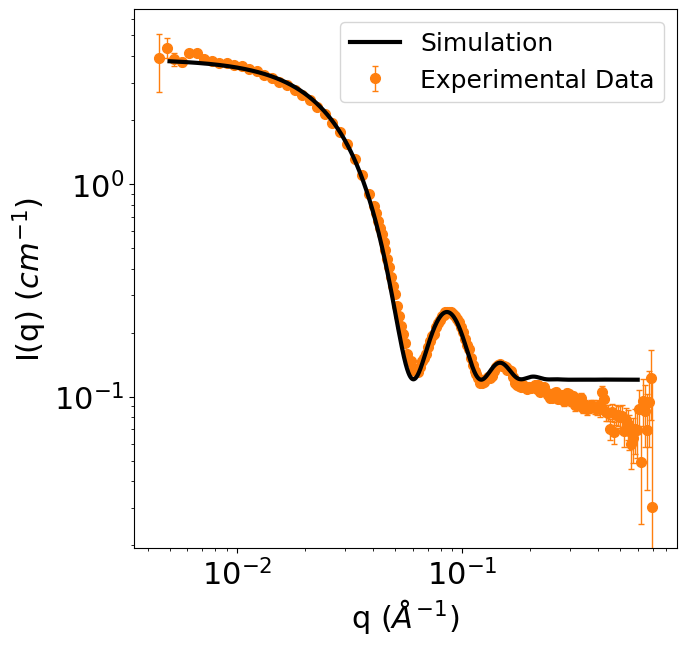

In [17]:
plt.rcParams.update({'font.size': 22})
fig, ax = plt.subplots(figsize=(7,7))
background = 1.2e-1
#background = 0 

plt.errorbar(
    exp_data[:,0], exp_data[:,1],
    yerr=exp_data[:,2],
    fmt='o',
    markersize=7,
    capsize=2,
    elinewidth=1,
    color = 'C1',
    ecolor='C1',
    zorder=0,
    label='Experimental Data'
)
plt.plot(q, I_q*2.2e-6 + background, linewidth = 3, label = 'Simulation', color ='k')
plt.yscale('log')
plt.xscale('log')
plt.ylabel('I(q) ($cm^{-1}$)')
plt.xlabel('q ($\\AA^{-1}$)')
ax.minorticks_on()
# plt.xlim([0.003, .2])
# plt.ylim([1e-10, 1e1])

plt.legend(fontsize=18)
#plt.savefig('../Images/Proteins_Churros_all.png', dpi=300, bbox_inches="tight")
#plt.savefig('../Images/Ferritin_Cage.png', dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
# # Code to save the scattering data
# best_fit = np.hstack((q.reshape(-1,1), (I_q*2.2e-6 + background).reshape(-1,1)))
# np.savetxt(
#     "../Data/ferritin/simulated_ferratin_cage_highq.txt",
#     best_fit,
#     header="q  I(q)",
#     comments="",
#     fmt="%.6e"
# )

In [ ]:
# # Code to save the scattering data
# best_fit = np.hstack((q.reshape(-1,1), (I_q*2.2e-6 + background).reshape(-1,1)))
# df = pd.DataFrame(best_fit, columns=['q','I'])
# df.to_csv("../Data/ferritin/simulated_ferratin_cage_highq.csv", index=False)

## Verify what structure was simulated

In [10]:
struc = simulator.structure_coordinates_1

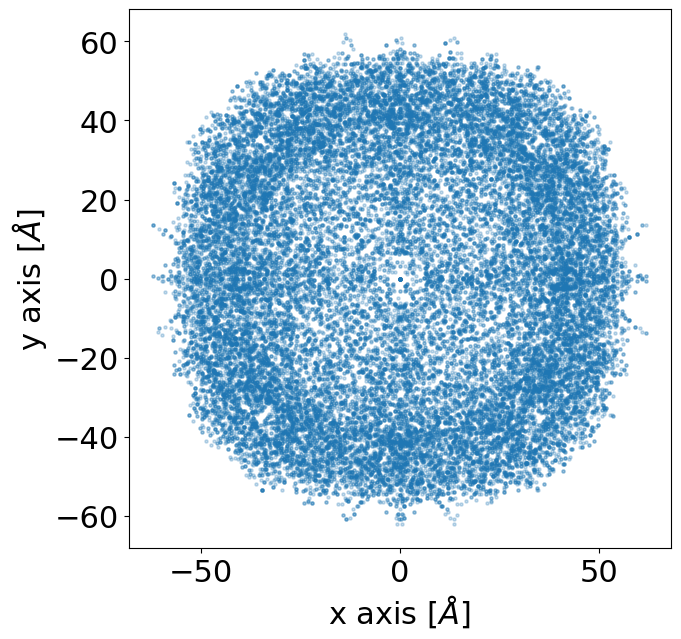

In [11]:
fig, ax = plt.subplots(figsize=(7,7))
plt.scatter(struc[:,0][::50], struc[:,1][::50], alpha = 0.25, s=5)
plt.xlabel('x axis [$\\AA$]')
plt.ylabel('y axis [$\\AA$]')
#plt.axis('off')
#plt.savefig('../Images/Sampled_Electron_Density_Tube_assembly_2.png', dpi=300, bbox_inches="tight")
plt.show()